# ETAPA 3. Pronóstico de PM2.5 con series de tiempo y Machine / Deep Learning

## Encuadre: contaminación por meteorología, **sin** tráfico

Este notebook deja de lado por completo el ángulo de **tráfico vehicular / horas
pico**. El objetivo es pronosticar la concentración horaria de `PM2.5` a partir de
(i) su propia historia reciente y (ii) las **condiciones meteorológicas**, para
entender cómo el clima favorece la **acumulación o la dispersión** de partículas.

Las variables de calendario (hora, día de la semana, mes) se usan únicamente como
**estacionalidad genérica** — el ciclo diario de la capa límite atmosférica y el
ciclo anual de temporada seca/lluvias — y **no** se interpretan como actividad
vehicular.

### Lo que cubre este notebook

| Tema | Sección |
|---|---|
| 1 contaminante (`PM2.5`) y 2 estaciones **no cercanas** (NE y SO) | 1 |
| Series de tiempo horarias por estación | 2 |
| Autocorrelación de la serie y de los predictores (ACF/PACF, ADF) | 3 |
| Variables climatológicas y de tiempo (features) | 4 |
| Revisión bibliográfica: ML/DL para pronóstico de PM2.5 | 5 |
| Modelo base de series de tiempo con exógenas: SARIMAX | 6 |
| Machine Learning: Random Forest y XGBoost | 7 |
| Deep Learning: LSTM (PyTorch) | 8 |
| Comparación de desempeño con **intervalos de confianza** (bootstrap por bloques) | 9 |
| **Análisis de error** y **gráficos de errores** | 10 |
| **Análisis de homocedasticidad** (Breusch–Pagan, White, ARCH) | 11 |
| **Autocorrelación de los residuos** (ACF, Ljung–Box, Durbin–Watson) | 12 |
| **Intervalos de predicción** y cobertura empírica | 13 |
| Conclusiones | 14 |

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import (
    het_breuschpagan, het_white, het_arch, acorr_ljungbox,
)
from statsmodels.stats.stattools import durbin_watson

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.3f}".format)
sns.set_theme(style="whitegrid", context="notebook")

try:                       # 'display' existe en Jupyter; fuera de Jupyter se usa print
    display                 # noqa: F821
except NameError:
    display = print

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
rng = np.random.default_rng(SEED)

DATA_PATH = Path("output/sima_2020_2025_limpio.parquet")
if not DATA_PATH.exists():
    raise FileNotFoundError(f"No se encontró {DATA_PATH}. Corre primero limpieza_datos.ipynb.")

df = pd.read_parquet(DATA_PATH)
df["fecha_hora"] = pd.to_datetime(df["fecha_hora"])

TARGET = "PM2.5"
ESTACIONES = ["NE", "SO"]
METEO = ["TOUT", "RH", "SR", "WSR", "WDR", "RAINF", "PRS"]
CONTEXTO = ["PM10"]  # familia PM2.5-PM10: PM10 entra como variable de contexto, no como objetivo

print(f"Base: {DATA_PATH}")
print(f"Registros: {len(df):,} | Periodo: {df['fecha_hora'].min()} a {df['fecha_hora'].max()}")

Base: output\sima_2020_2025_limpio.parquet
Registros: 688,184 | Periodo: 2020-01-01 00:00:00 a 2025-06-30 23:00:00


## 1. Contaminante y estaciones de monitoreo no cercanas

**Contaminante (uno solo): `PM2.5`.** De la pareja `PM2.5`–`PM10` se modela `PM2.5`
(el de mayor relevancia sanitaria); `PM10` se conserva como variable climatológica /
de contexto en los modelos de Machine Learning.

**Estaciones (dos, no cercanas):**

| Clave | Zona | Ubicación (SIMA) | Municipio |
|---|---|---|---|
| **NE** | Noreste del AMM | Col. Unidad Laboral | San Nicolás de los Garza |
| **SO** | Suroeste del AMM | Zona Centro | Santa Catarina |

Están en **extremos opuestos** de la Zona Metropolitana de Monterrey (municipios
distintos, separación en línea recta del orden de **20–25 km**), así que no comparten
microclima ni fuentes locales inmediatas: es un contraste espacial real, no dos
sensores del mismo vecindario. Ambas tienen cobertura alta de `PM2.5`.

In [2]:
cobertura = (
    df[df["estación"].isin(ESTACIONES)]
    .groupby("estación", observed=True)
    .apply(lambda g: pd.Series({
        "registros": len(g),
        "nulos_PM2.5_%": g["PM2.5"].isna().mean() * 100,
        "nulos_PM10_%": g["PM10"].isna().mean() * 100,
        "nulos_meteo_%": g[METEO].isna().mean().mean() * 100,
        "inicio": g["fecha_hora"].min(),
        "fin": g["fecha_hora"].max(),
    }), include_groups=False)
)
display(cobertura)

,registros,nulos_PM2.5_%,nulos_PM10_%,nulos_meteo_%,inicio,fin
estación,,,,,,
NE,48180,3.898,1.723,7.731,2020-01-01,2025-06-30 23:00:00
SO,48041,5.995,1.786,3.957,2020-01-01,2025-06-30 23:00:00


## 2. Construcción de series de tiempo horarias por estación

Cada estación se reindexa a una **malla horaria completa** (sin huecos en el índice).
Así los periodos sin medición quedan explícitos y se manejan según el modelo
(los rezagos y las ventanas móviles requieren continuidad temporal).

In [3]:
def construir_serie(estacion, variables):
    d = (df.loc[df["estación"] == estacion, ["fecha_hora"] + variables]
           .set_index("fecha_hora"))
    d = d[~d.index.duplicated(keep="first")].sort_index()
    idx = pd.date_range(d.index.min(), d.index.max(), freq="h")
    return d.reindex(idx)


series_horarias = {est: construir_serie(est, [TARGET] + METEO + CONTEXTO) for est in ESTACIONES}
for est, s in series_horarias.items():
    obs = s[TARGET].notna().sum()
    print(f"{est}: {len(s):,} horas en el rango, {obs:,} observadas ({obs/len(s):.1%})")

NE: 48,192 horas en el rango, 46,302 observadas (96.1%)
SO: 48,192 horas en el rango, 45,161 observadas (93.7%)


## 3. Autocorrelación de la serie y de los predictores

Antes de modelar se revisa la **estructura de autocorrelación**, porque condiciona
todo lo que sigue:

- una serie muy autocorrelacionada hace que un pronóstico ingenuo (`PM2.5(t+1) = PM2.5(t)`)
  sea un piso difícil de superar;
- si además los **predictores meteorológicos** están autocorrelacionados, el número
  de observaciones *efectivas* es mucho menor que el número de horas, y los intervalos
  de confianza calculados como si las horas fueran independientes salen **demasiado
  angostos**. Esto se retoma en la sección 9 con un *bootstrap por bloques*.

Se calcula: ACF y PACF de `PM2.5` (horaria y diaria), prueba ADF de estacionariedad,
descomposición estacional y la autocorrelación de rezago 1 de cada predictor.

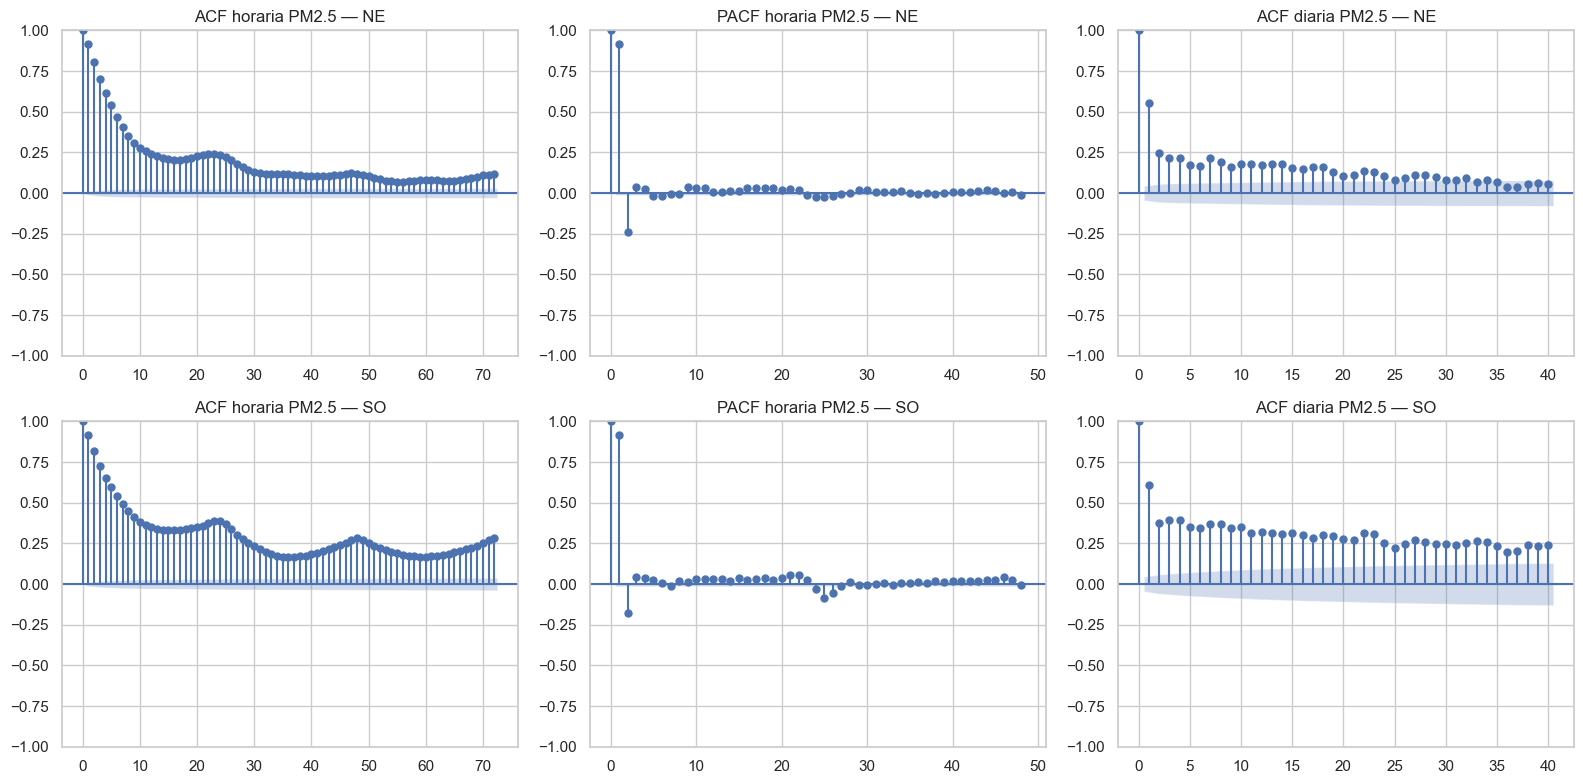

In [4]:
fig, axes = plt.subplots(len(ESTACIONES), 3, figsize=(16, 4 * len(ESTACIONES)))
series_diarias = {}
for fila, est in enumerate(ESTACIONES):
    s_h = series_horarias[est][TARGET]
    s_d = s_h.resample("D").mean()
    series_diarias[est] = s_d

    plot_acf(s_h.dropna(), lags=72, ax=axes[fila, 0], title=f"ACF horaria PM2.5 — {est}")
    plot_pacf(s_h.dropna(), lags=48, ax=axes[fila, 1], method="ywm",
              title=f"PACF horaria PM2.5 — {est}")
    plot_acf(s_d.dropna(), lags=40, ax=axes[fila, 2], title=f"ACF diaria PM2.5 — {est}")
plt.tight_layout()
plt.show()

C:\Users\andre\AppData\Local\Temp\ipykernel_18040\3124064856.py:7: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf = adfuller(s_d, autolag="AIC")


NE — ADF: estadístico=-7.045, p=0.0000 -> estacionaria al 5%
     autocorrelación diaria de rezago 1: 0.565


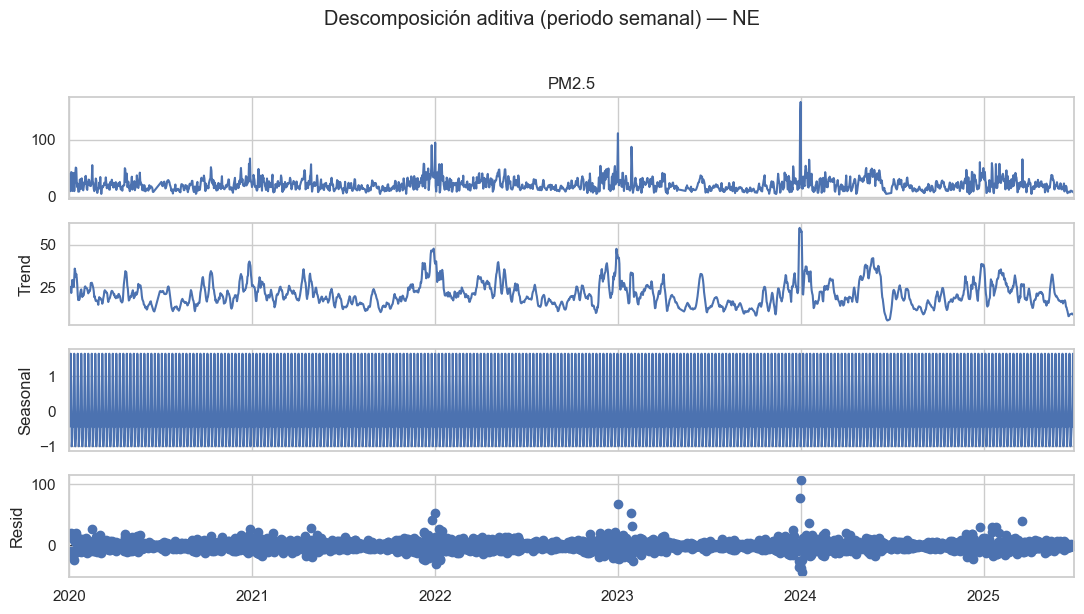

C:\Users\andre\AppData\Local\Temp\ipykernel_18040\3124064856.py:7: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf = adfuller(s_d, autolag="AIC")


SO — ADF: estadístico=-4.035, p=0.0012 -> estacionaria al 5%
     autocorrelación diaria de rezago 1: 0.633


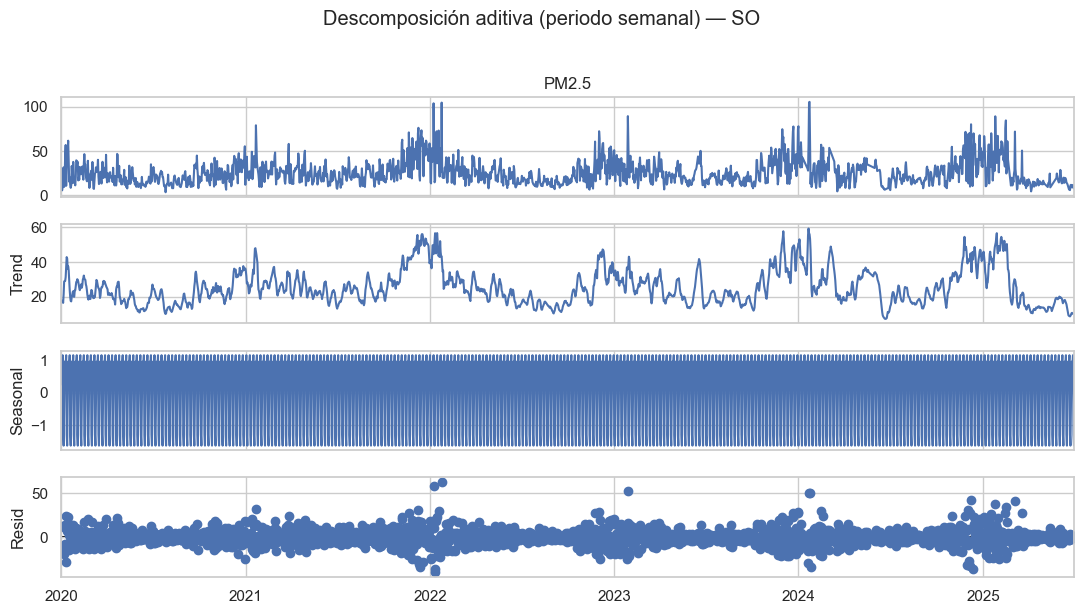

In [5]:
def interpolar_diaria(s):
    return s.asfreq("D").interpolate(limit_direction="both").ffill().bfill()


for est in ESTACIONES:
    s_d = interpolar_diaria(series_diarias[est])
    adf = adfuller(s_d, autolag="AIC")
    print(f"{est} — ADF: estadístico={adf[0]:.3f}, p={adf[1]:.4f} -> "
          f"{'estacionaria' if adf[1] < 0.05 else 'NO estacionaria'} al 5%")
    r1 = acf(s_d, nlags=1, fft=False)[1]
    print(f"     autocorrelación diaria de rezago 1: {r1:.3f}")

    dec = seasonal_decompose(s_d, model="additive", period=7)
    fig = dec.plot(); fig.set_size_inches(11, 6)
    fig.suptitle(f"Descomposición aditiva (periodo semanal) — {est}", y=1.02)
    plt.tight_layout(); plt.show()

In [6]:
# Autocorrelación de rezago 1 de los predictores (horaria) — muestra que NO son ruido blanco
filas_acf = []
for est in ESTACIONES:
    s = series_horarias[est]
    for v in [TARGET] + METEO + CONTEXTO:
        serie = s[v].dropna()
        filas_acf.append({"estación": est, "variable": v,
                          "acf_lag1": acf(serie, nlags=1, fft=False)[1],
                          "acf_lag24": acf(serie, nlags=24, fft=False)[24]})
tabla_acf = pd.DataFrame(filas_acf).pivot(index="variable", columns="estación",
                                          values=["acf_lag1", "acf_lag24"])
print("Autocorrelación de los predictores (lag 1h y lag 24h):")
display(tabla_acf.round(3))
print("\nTodos los predictores tienen acf_lag1 alta -> las horas NO son observaciones "
      "independientes. Se tendrá en cuenta al construir intervalos de confianza (sección 9).")

Autocorrelación de los predictores (lag 1h y lag 24h):


acf_lag1       acf_lag24      
estación       NE    SO        NE    SO
variable                               
PM10        0.880 0.830     0.366 0.382
PM2.5       0.917 0.918     0.236 0.390
PRS         0.943 0.982     0.606 0.684
RAINF       0.342 0.920     0.047 0.007
RH          0.973 0.971     0.701 0.677
SR          0.917 0.922     0.873 0.588
TOUT        0.985 0.986     0.860 0.858
WDR         0.604 0.708     0.272 0.481
WSR         0.886 0.917     0.550 0.643


Todos los predictores tienen acf_lag1 alta -> las horas NO son observaciones independientes. Se tendrá en cuenta al construir intervalos de confianza (sección 9).


## 4. Variables climatológicas y de tiempo (features)

Para pronosticar `PM2.5` en `t+1` con información disponible **hasta `t`** se construyen:

- **Rezagos de `PM2.5`:** 1, 2, 3, 6, 12, 24, 48 y 168 horas (168h = patrón semanal).
- **Estadísticas móviles:** media y desviación de las últimas 24 y 168 horas.
- **Tiempo (estacionalidad, no tráfico):** hora, día de la semana, mes, y sus
  codificaciones seno/coseno para que el modelo trate la hora y el mes como cíclicos.
- **Variables climatológicas en `t-1`:** `TOUT`, `RH`, `SR`, `WSR`, `WDR`, `RAINF`,
  `PRS` — rezagadas una hora para no suponer que se conoce la meteorología futura.
- **Contexto `PM10` en `t-1`.**

Cualquier fila con datos faltantes en features u objetivo se descarta (sin imputación
artificial en el entrenamiento).

In [7]:
LAGS = [1, 2, 3, 6, 12, 24, 48, 168]
VENTANAS = [24, 168]


def construir_features(estacion):
    d = series_horarias[estacion]
    X = pd.DataFrame(index=d.index)
    for L in LAGS:
        X[f"{TARGET}_lag{L}h"] = d[TARGET].shift(L)
    for W in VENTANAS:
        X[f"{TARGET}_media{W}h"] = d[TARGET].shift(1).rolling(W).mean()
        X[f"{TARGET}_std{W}h"] = d[TARGET].shift(1).rolling(W).std()

    h = X.index.hour.to_numpy()
    m = X.index.month.to_numpy()
    X["hora"] = h
    X["dia_semana"] = X.index.dayofweek
    X["mes"] = m
    X["hora_sin"] = np.sin(2 * np.pi * h / 24)
    X["hora_cos"] = np.cos(2 * np.pi * h / 24)
    X["mes_sin"] = np.sin(2 * np.pi * m / 12)
    X["mes_cos"] = np.cos(2 * np.pi * m / 12)

    for v in METEO + CONTEXTO:
        X[f"{v}_lag1h"] = d[v].shift(1)

    y = d[TARGET]
    tabla = pd.concat([X, y.rename("y")], axis=1).dropna()
    return tabla.drop(columns="y"), tabla["y"]


for est in ESTACIONES:
    X, y = construir_features(est)
    print(f"{est}: {len(X):,} horas utilizables, {X.shape[1]} predictores "
          f"({X.index.min()} a {X.index.max()})")

NE: 24,211 horas utilizables, 27 predictores (2020-01-18 12:00:00 a 2025-03-11 03:00:00)
SO: 30,051 horas utilizables, 27 predictores (2020-01-14 22:00:00 a 2025-03-31 03:00:00)


## 6. Modelo base de series de tiempo: SARIMAX con exógenas meteorológicas

Sobre la serie **diaria** de cada estación (menos ruidosa que la horaria para el
modelado clásico) se ajusta un `SARIMAX` con:

- estacionalidad **semanal** (`s = 7`);
- **variables exógenas**: el promedio diario de la meteorología (`TOUT`, `RH`, `SR`,
  `WSR`, `WDR`, `RAINF`, `PRS`).

La partición es estrictamente cronológica: los últimos **60 días** son prueba.
`SARIMAX` entrega de forma nativa **intervalos de confianza** del pronóstico.

C:\Users\andre\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


C:\Users\andre\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


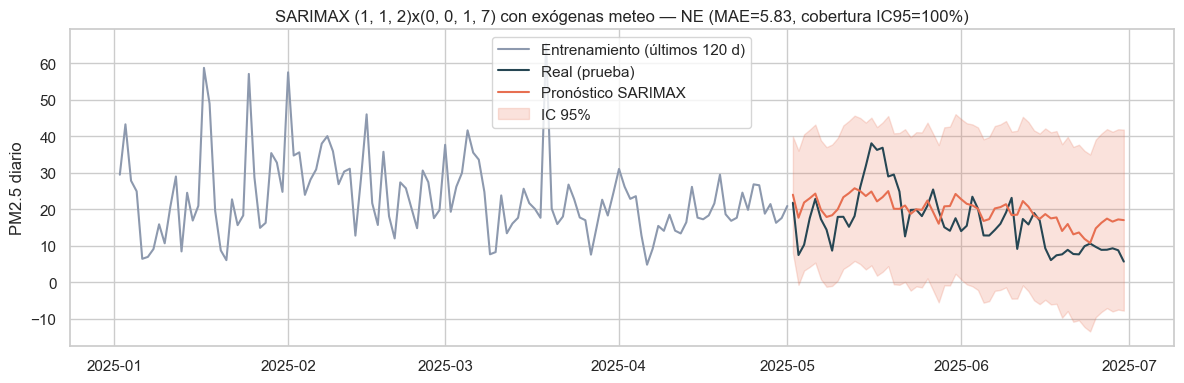

C:\Users\andre\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


C:\Users\andre\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


C:\Users\andre\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


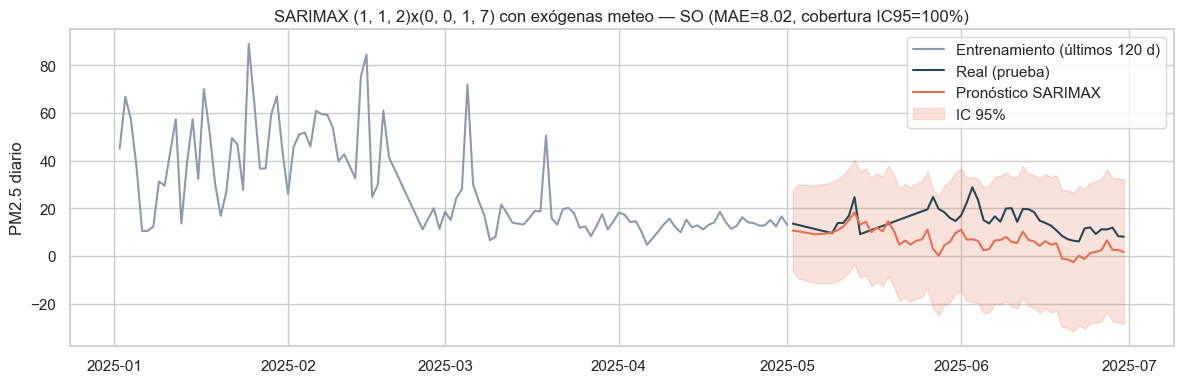

,orden,AIC,MAE_diario,RMSE_diario,cobertura_IC95
NE,"((1, 1, 2), (0, 0, 1, 7))",13633.603,5.833,6.865,1.000
SO,"((1, 1, 2), (0, 0, 1, 7))",13912.682,8.017,9.550,1.000


In [8]:
DIAS_PRUEBA = 60
ORDENES = [((1, 1, 1), (1, 0, 1, 7)), ((2, 1, 1), (1, 0, 1, 7)), ((1, 1, 2), (0, 0, 1, 7))]

meteo_diaria = {
    est: construir_serie(est, METEO).resample("D").mean()
    for est in ESTACIONES
}
resultados_sarimax = {}

for est in ESTACIONES:
    y_d = interpolar_diaria(series_diarias[est])
    X_d = meteo_diaria[est].reindex(y_d.index).interpolate(limit_direction="both").ffill().bfill()

    y_tr, y_te = y_d.iloc[:-DIAS_PRUEBA], y_d.iloc[-DIAS_PRUEBA:]
    X_tr, X_te = X_d.iloc[:-DIAS_PRUEBA], X_d.iloc[-DIAS_PRUEBA:]

    mejor = None
    for orden, est_orden in ORDENES:
        try:
            mod = SARIMAX(y_tr, exog=X_tr, order=orden, seasonal_order=est_orden,
                          enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
        except Exception:
            continue
        if mejor is None or mod.aic < mejor[0]:
            mejor = (mod.aic, (orden, est_orden), mod)

    aic, orden_final, modelo = mejor
    fc = modelo.get_forecast(steps=DIAS_PRUEBA, exog=X_te)
    pred = fc.predicted_mean
    ic = fc.conf_int(alpha=0.05)

    mae = mean_absolute_error(y_te, pred)
    rmse = np.sqrt(mean_squared_error(y_te, pred))
    cobertura_ic = ((y_te >= ic.iloc[:, 0]) & (y_te <= ic.iloc[:, 1])).mean()
    resultados_sarimax[est] = {"orden": orden_final, "AIC": aic, "MAE_diario": mae,
                               "RMSE_diario": rmse, "cobertura_IC95": cobertura_ic,
                               "modelo": modelo}

    plt.figure(figsize=(12, 4))
    plt.plot(y_tr.index[-120:], y_tr.values[-120:], label="Entrenamiento (últimos 120 d)", color="#8d99ae")
    plt.plot(y_te.index, y_te.values, label="Real (prueba)", color="#264653")
    plt.plot(pred.index, pred.values, label="Pronóstico SARIMAX", color="#e76f51")
    plt.fill_between(ic.index, ic.iloc[:, 0], ic.iloc[:, 1], color="#e76f51", alpha=0.2, label="IC 95%")
    plt.title(f"SARIMAX {orden_final[0]}x{orden_final[1]} con exógenas meteo — {est} "
              f"(MAE={mae:.2f}, cobertura IC95={cobertura_ic:.0%})")
    plt.ylabel("PM2.5 diario"); plt.legend(); plt.tight_layout(); plt.show()

tabla_sarimax = pd.DataFrame({k: {kk: vv for kk, vv in v.items() if kk != "modelo"}
                              for k, v in resultados_sarimax.items()}).T
display(tabla_sarimax)

## 7. Machine Learning: Random Forest y XGBoost

Pronóstico horario a `t+1` con las features de la sección 4. Se incluye un
**pronóstico ingenuo** (`PM2.5(t+1) = PM2.5(t)`) como piso de comparación.

In [9]:
def dividir_temporal(X, y, dias=DIAS_PRUEBA):
    h = dias * 24
    return X.iloc[:-h], X.iloc[-h:], y.iloc[:-h], y.iloc[-h:]


def metricas(y_real, y_pred):
    y_real = np.asarray(y_real, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    err = y_real - y_pred
    mae = np.mean(np.abs(err))
    rmse = np.sqrt(np.mean(err ** 2))
    with np.errstate(divide="ignore", invalid="ignore"):
        mape = np.nanmean(np.abs(err) / np.where(y_real == 0, np.nan, y_real)) * 100
    return {"ME_sesgo": np.mean(err), "MAE": mae, "RMSE": rmse, "MAPE_%": mape}


ml = {}
filas_ml = []
for est in ESTACIONES:
    X, y = construir_features(est)
    X_tr, X_te, y_tr, y_te = dividir_temporal(X, y)

    pred_naive = X_te[f"{TARGET}_lag1h"].to_numpy()

    rf = RandomForestRegressor(n_estimators=300, max_depth=16, min_samples_leaf=3,
                               random_state=SEED, n_jobs=-1).fit(X_tr, y_tr)
    pred_rf = rf.predict(X_te)

    xgb = XGBRegressor(n_estimators=500, max_depth=6, learning_rate=0.05,
                       subsample=0.8, colsample_bytree=0.8, random_state=SEED, n_jobs=-1).fit(X_tr, y_tr)
    pred_xgb = xgb.predict(X_te)

    ml[est] = {"X_tr": X_tr, "X_te": X_te, "y_tr": y_tr, "y_te": y_te,
               "rf": rf, "xgb": xgb,
               "pred": {"Naive (t-1)": pred_naive, "Random Forest": pred_rf, "XGBoost": pred_xgb}}
    for nombre, p in ml[est]["pred"].items():
        filas_ml.append({"estación": est, "modelo": nombre, **metricas(y_te, p)})

tabla_ml = pd.DataFrame(filas_ml)
display(tabla_ml.set_index(["estación", "modelo"]).round(3))

ME_sesgo   MAE   RMSE  MAPE_%
estación modelo                                      
NE       Naive (t-1)      -0.038 3.139  8.167  13.602
         Random Forest    -0.031 3.026  7.423  13.681
         XGBoost           0.094 3.148  7.245  13.862
SO       Naive (t-1)      -0.034 6.247 11.241  19.514
         Random Forest    -0.245 5.798 10.352  19.885
         XGBoost           0.000 6.000 11.019  20.728

In [10]:
# Modelo campeón por estación (menor MAE), sobre el que se hace el análisis de residuos
campeon = {}
for est in ESTACIONES:
    sub = tabla_ml[tabla_ml["estación"] == est].set_index("modelo")["MAE"]
    campeon[est] = sub.idxmin()
    print(f"{est}: modelo campeón = {campeon[est]} (MAE={sub.min():.3f})")

NE: modelo campeón = Random Forest (MAE=3.026)
SO: modelo campeón = Random Forest (MAE=5.798)


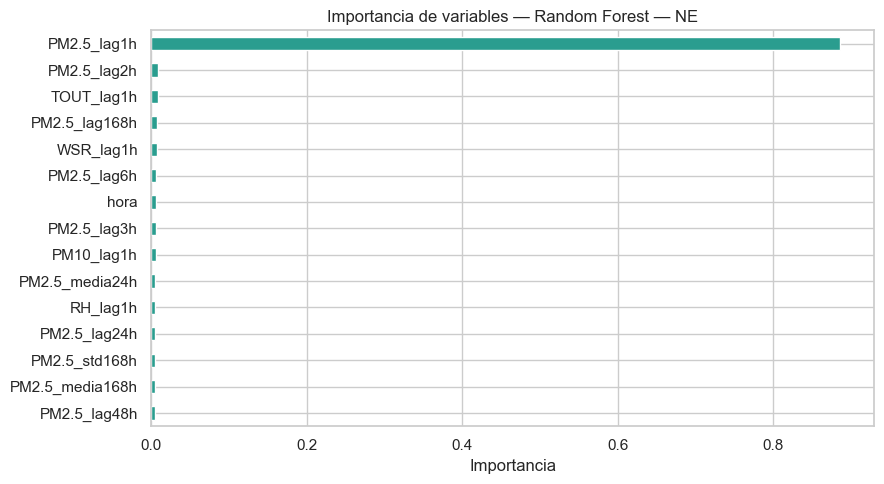

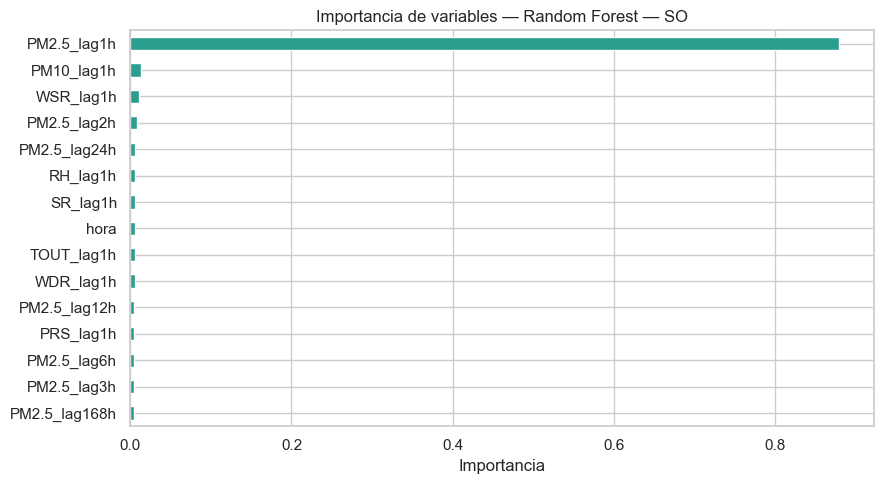

In [11]:
# Importancia de variables del campeón basado en árboles (si aplica)
for est in ESTACIONES:
    nombre = campeon[est]
    modelo = ml[est]["rf"] if nombre == "Random Forest" else ml[est].get("xgb")
    if nombre == "Naive (t-1)":
        print(f"{est}: el campeón es el ingenuo; se reporta también Random Forest por interpretabilidad.")
        modelo = ml[est]["rf"]; nombre = "Random Forest (referencia)"
    imp = pd.Series(modelo.feature_importances_, index=ml[est]["X_tr"].columns).sort_values().tail(15)
    imp.plot(kind="barh", figsize=(9, 5), color="#2a9d8f")
    plt.title(f"Importancia de variables — {nombre} — {est}")
    plt.xlabel("Importancia"); plt.tight_layout(); plt.show()

## 8. Deep Learning: LSTM (PyTorch)

La LSTM recibe la **secuencia** de las últimas `W = 24` horas de `PM2.5` + meteo +
`PM10` y aprende la dependencia temporal directamente. El escalador se ajusta solo
con entrenamiento (sin fuga de información).

In [12]:
VENTANA = 24
VARS_LSTM = [TARGET] + METEO + CONTEXTO


def construir_secuencias(estacion, ventana=VENTANA):
    d = series_horarias[estacion][VARS_LSTM].dropna()
    v = d.to_numpy("float32")
    j = VARS_LSTM.index(TARGET)
    Xs, ys, ts = [], [], []
    for fin in range(ventana, len(v)):
        Xs.append(v[fin - ventana:fin]); ys.append(v[fin, j]); ts.append(d.index[fin])
    return np.array(Xs), np.array(ys, "float32"), pd.DatetimeIndex(ts)


class RedLSTM(nn.Module):
    def __init__(self, n_vars, oculto=48):
        super().__init__()
        self.lstm = nn.LSTM(n_vars, oculto, batch_first=True)
        self.cabeza = nn.Linear(oculto, 1)

    def forward(self, x):
        s, _ = self.lstm(x)
        return self.cabeza(s[:, -1, :]).squeeze(-1)


def entrenar_lstm(estacion, epocas=18, lote=256, lr=1e-3):
    Xs, ys, ts = construir_secuencias(estacion)
    h = DIAS_PRUEBA * 24
    Xtr, Xte, ytr, yte, tte = Xs[:-h], Xs[-h:], ys[:-h], ys[-h:], ts[-h:]

    mu = Xtr.reshape(-1, Xtr.shape[-1]).mean(0)
    sd = Xtr.reshape(-1, Xtr.shape[-1]).std(0) + 1e-6
    Xtr = (Xtr - mu) / sd
    Xte = (Xte - mu) / sd
    j = VARS_LSTM.index(TARGET)
    muy, sdy = mu[j], sd[j]

    cargador = DataLoader(TensorDataset(torch.from_numpy(Xtr),
                                        torch.from_numpy(((ytr - muy) / sdy).astype("float32"))),
                          batch_size=lote, shuffle=True)
    modelo = RedLSTM(len(VARS_LSTM))
    opt = torch.optim.Adam(modelo.parameters(), lr=lr)
    perdida_fn = nn.MSELoss()
    hist = []
    modelo.train()
    for _ in range(epocas):
        tot = 0.0
        for bx, by in cargador:
            opt.zero_grad()
            p = modelo(bx)
            loss = perdida_fn(p, by)
            loss.backward()
            opt.step()
            tot += loss.item() * bx.size(0)
        hist.append(tot / len(cargador.dataset))

    modelo.eval()
    with torch.no_grad():
        pred = modelo(torch.from_numpy(Xte)).numpy() * sdy + muy
    return {"pred": pred, "y_te": pd.Series(yte, index=tte), "hist": hist}


lstm = {}
for est in ESTACIONES:
    print(f"Entrenando LSTM — {est} ...")
    lstm[est] = entrenar_lstm(est)
    lstm[est]["serie_pred"] = pd.Series(lstm[est]["pred"], index=lstm[est]["y_te"].index)
    m = metricas(lstm[est]["y_te"].to_numpy(), lstm[est]["pred"])
    lstm[est]["metricas"] = m
    print(f"  MAE={m['MAE']:.3f} | RMSE={m['RMSE']:.3f}  "
          f"(conjunto de prueba propio de la LSTM: {len(lstm[est]['y_te']):,} horas)")

Entrenando LSTM — NE ...


  MAE=3.736 | RMSE=9.216  (conjunto de prueba propio de la LSTM: 1,440 horas)
Entrenando LSTM — SO ...


  MAE=5.964 | RMSE=11.093  (conjunto de prueba propio de la LSTM: 1,440 horas)


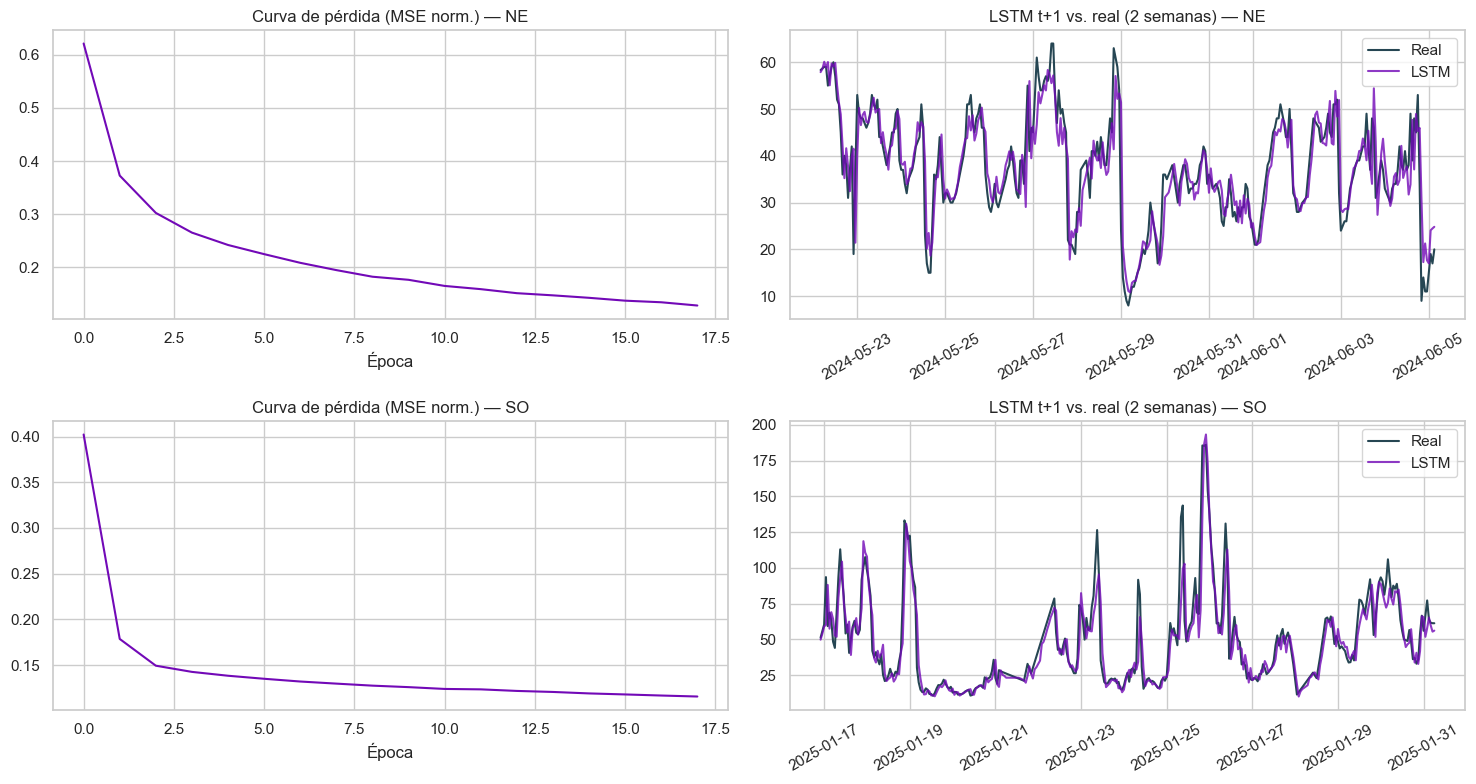

In [13]:
fig, axes = plt.subplots(len(ESTACIONES), 2, figsize=(15, 4 * len(ESTACIONES)))
for fila, est in enumerate(ESTACIONES):
    axes[fila, 0].plot(lstm[est]["hist"], color="#7209b7")
    axes[fila, 0].set_title(f"Curva de pérdida (MSE norm.) — {est}")
    axes[fila, 0].set_xlabel("Época")

    yv = lstm[est]["y_te"].iloc[:24 * 14]
    axes[fila, 1].plot(yv.index, yv.values, label="Real", color="#264653")
    pv = pd.Series(lstm[est]["pred"], index=lstm[est]["y_te"].index).loc[yv.index]
    axes[fila, 1].plot(yv.index, pv.values, label="LSTM", color="#7209b7", alpha=0.8)
    axes[fila, 1].set_title(f"LSTM t+1 vs. real (2 semanas) — {est}")
    axes[fila, 1].legend(); axes[fila, 1].tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()

## 9. Comparación de desempeño con intervalos de confianza

Los modelos **tabulares** (ingenuo, Random Forest, XGBoost) se comparan sobre el
**mismo índice horario de prueba** (el de las features). La **LSTM** se reporta
sobre su propio conjunto de prueba y se marca como *no directamente comparable*,
porque su manejo de huecos (requiere secuencias de 24 h completas) deja un subconjunto
de horas distinto — por la misma razón, SARIMAX se evalúa a escala diaria y aparte.

Para las métricas de error **no basta el valor puntual**: como las horas están
autocorrelacionadas (sección 3), el error de un día se parece al del siguiente.
Por eso el intervalo de confianza del MAE y del RMSE se calcula con un
**bootstrap por bloques de día** (se remuestrean días completos con reemplazo,
2 000 réplicas), que respeta esa dependencia; un bootstrap por horas sueltas daría
un intervalo artificialmente angosto.

In [14]:
def bloque_bootstrap_metricas(y_real, y_pred, indice, reps=2000):
    dfb = pd.DataFrame({"e": np.asarray(y_real) - np.asarray(y_pred),
                        "abs": np.abs(np.asarray(y_real) - np.asarray(y_pred))},
                       index=pd.DatetimeIndex(indice))
    dfb["dia"] = dfb.index.normalize()
    grupos = [g for _, g in dfb.groupby("dia")]
    n = len(grupos)
    maes = np.empty(reps); rmses = np.empty(reps)
    for i in range(reps):
        muestra = pd.concat([grupos[k] for k in rng.integers(0, n, n)])
        maes[i] = muestra["abs"].mean()
        rmses[i] = np.sqrt((muestra["e"] ** 2).mean())
    return (np.percentile(maes, [2.5, 97.5]), np.percentile(rmses, [2.5, 97.5]))


filas_ic = []
for est in ESTACIONES:
    idx = ml[est]["y_te"].index
    yv = ml[est]["y_te"].to_numpy()
    for nombre, p in ml[est]["pred"].items():          # solo modelos tabulares
        p = np.asarray(p, dtype=float)
        m = metricas(yv, p)
        ic_mae, ic_rmse = bloque_bootstrap_metricas(yv, p, idx)
        filas_ic.append({"estación": est, "modelo": nombre,
                         "MAE": m["MAE"], "MAE_IC95": f"[{ic_mae[0]:.2f}, {ic_mae[1]:.2f}]",
                         "RMSE": m["RMSE"], "RMSE_IC95": f"[{ic_rmse[0]:.2f}, {ic_rmse[1]:.2f}]",
                         "ME_sesgo": m["ME_sesgo"]})

tabla_ic = pd.DataFrame(filas_ic).set_index(["estación", "modelo"]).round(3)
print("Desempeño horario (t+1) — modelos tabulares, con IC 95% por bootstrap de bloques de día")
display(tabla_ic)

print("\nLSTM (conjunto de prueba propio, no directamente comparable):")
for est in ESTACIONES:
    m = lstm[est]["metricas"]
    print(f"  {est}: MAE={m['MAE']:.3f} | RMSE={m['RMSE']:.3f} | sesgo={m['ME_sesgo']:+.3f}")

Desempeño horario (t+1) — modelos tabulares, con IC 95% por bootstrap de bloques de día


MAE      MAE_IC95   RMSE      RMSE_IC95  ME_sesgo
estación modelo                                                           
NE       Naive (t-1)   3.139  [2.71, 3.74]  8.167  [4.07, 12.54]    -0.038
         Random Forest 3.026  [2.62, 3.59]  7.423  [3.87, 11.56]    -0.031
         XGBoost       3.148  [2.70, 3.70]  7.245  [3.95, 10.68]     0.094
SO       Naive (t-1)   6.247  [5.30, 7.28] 11.241  [9.30, 13.22]    -0.034
         Random Forest 5.798  [4.93, 6.71] 10.352  [8.34, 12.48]    -0.245
         XGBoost       6.000  [5.08, 6.88] 11.019  [8.86, 13.18]     0.000


LSTM (conjunto de prueba propio, no directamente comparable):
  NE: MAE=3.736 | RMSE=9.216 | sesgo=-0.239
  SO: MAE=5.964 | RMSE=11.093 | sesgo=+0.747


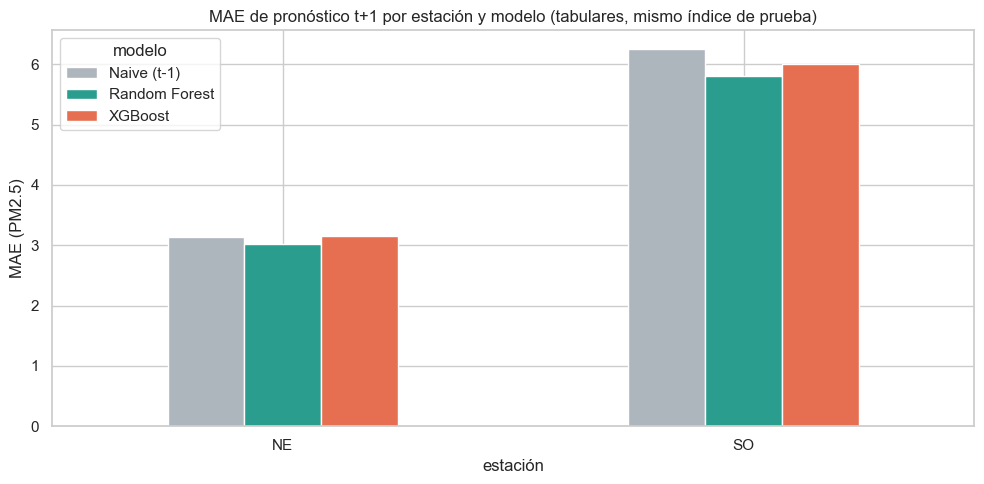

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))
piv = pd.DataFrame(filas_ic).pivot(index="estación", columns="modelo", values="MAE")
piv = piv[["Naive (t-1)", "Random Forest", "XGBoost"]]
piv.plot(kind="bar", ax=ax, color=["#adb5bd", "#2a9d8f", "#e76f51"])
ax.set_ylabel("MAE (PM2.5)")
ax.set_title("MAE de pronóstico t+1 por estación y modelo (tabulares, mismo índice de prueba)")
ax.tick_params(axis="x", rotation=0); plt.tight_layout(); plt.show()

## 10. Análisis de error y gráficos de errores

Sobre el **modelo campeón por estación** (sección 7) se analizan los residuos del
conjunto de prueba: `e(t) = PM2.5_real(t) - PM2.5_pronóstico(t)`.

Se revisa: sesgo medio (`ME`), error por hora del día, error por nivel observado
(cuartil), y cuatro gráficos de errores estándar.


=== NE — modelo campeón: Random Forest ===
  ME (sesgo)      : -0.031
  MAE             : 3.026
  RMSE            : 7.423
  % |error| <= 5  : 85.1%
  % |error| <= 10 : 96.5%
  Error por nivel observado de PM2.5:


,MAE,sesgo
q,,
bajo,2.120,-1.330
medio,2.770,-0.600
alto,2.700,0.190
muy_alto,4.590,1.690


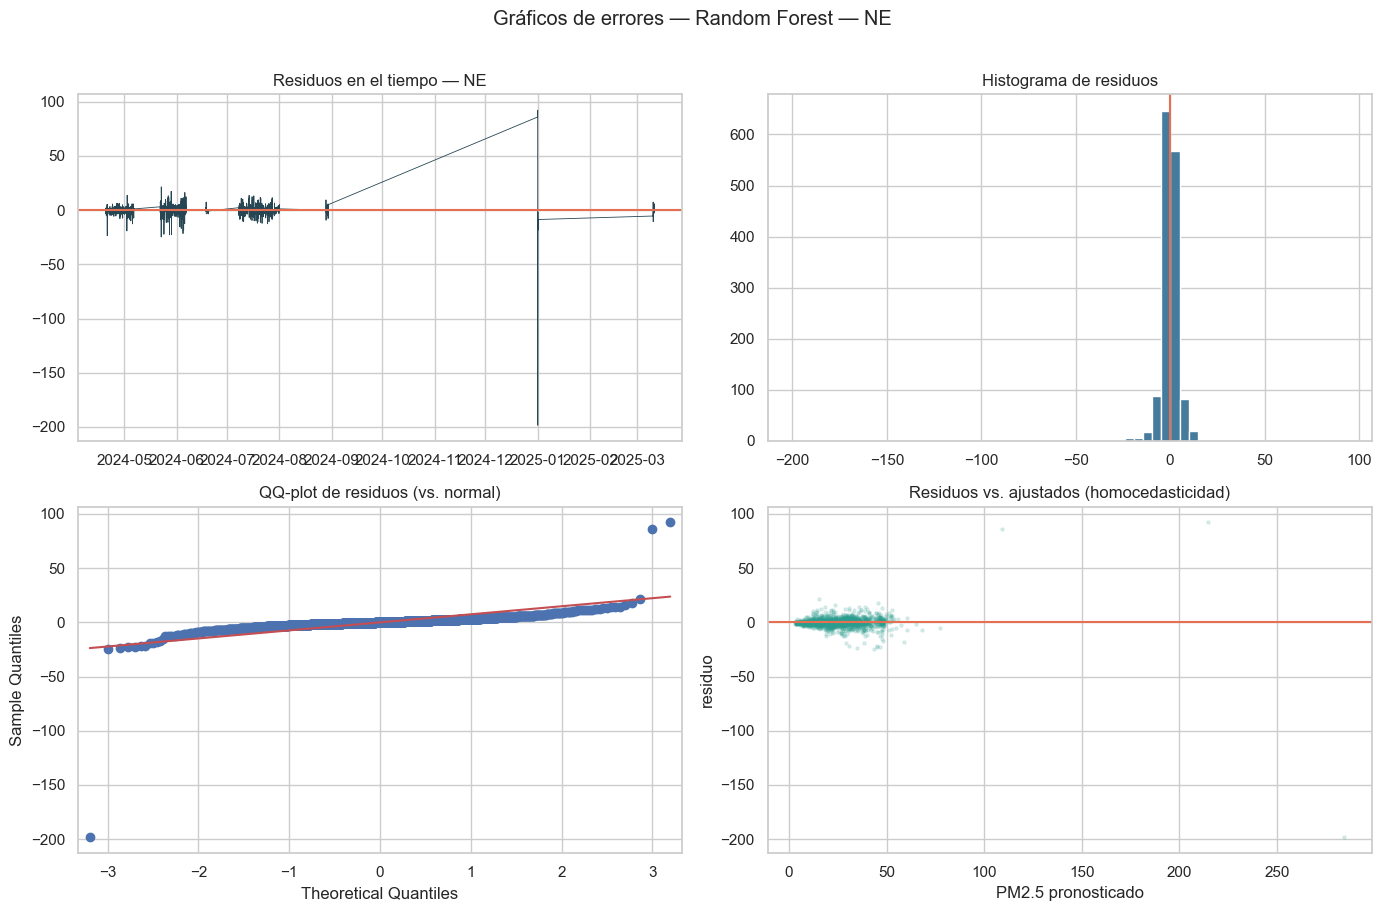

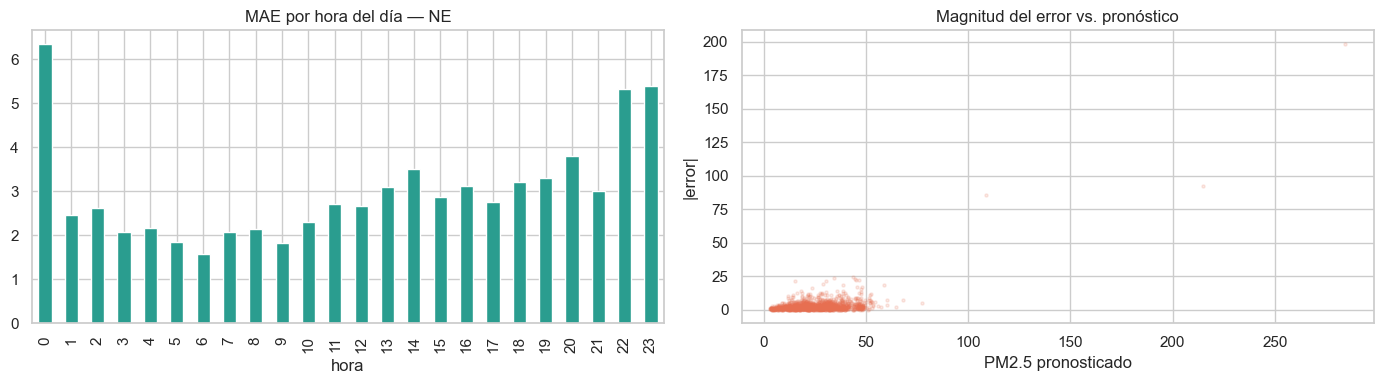


=== SO — modelo campeón: Random Forest ===
  ME (sesgo)      : -0.245
  MAE             : 5.798
  RMSE            : 10.352
  % |error| <= 5  : 64.2%
  % |error| <= 10 : 84.4%
  Error por nivel observado de PM2.5:


,MAE,sesgo
q,,
bajo,2.260,-1.850
medio,3.310,-1.600
alto,5.480,-1.830
muy_alto,12.140,4.300


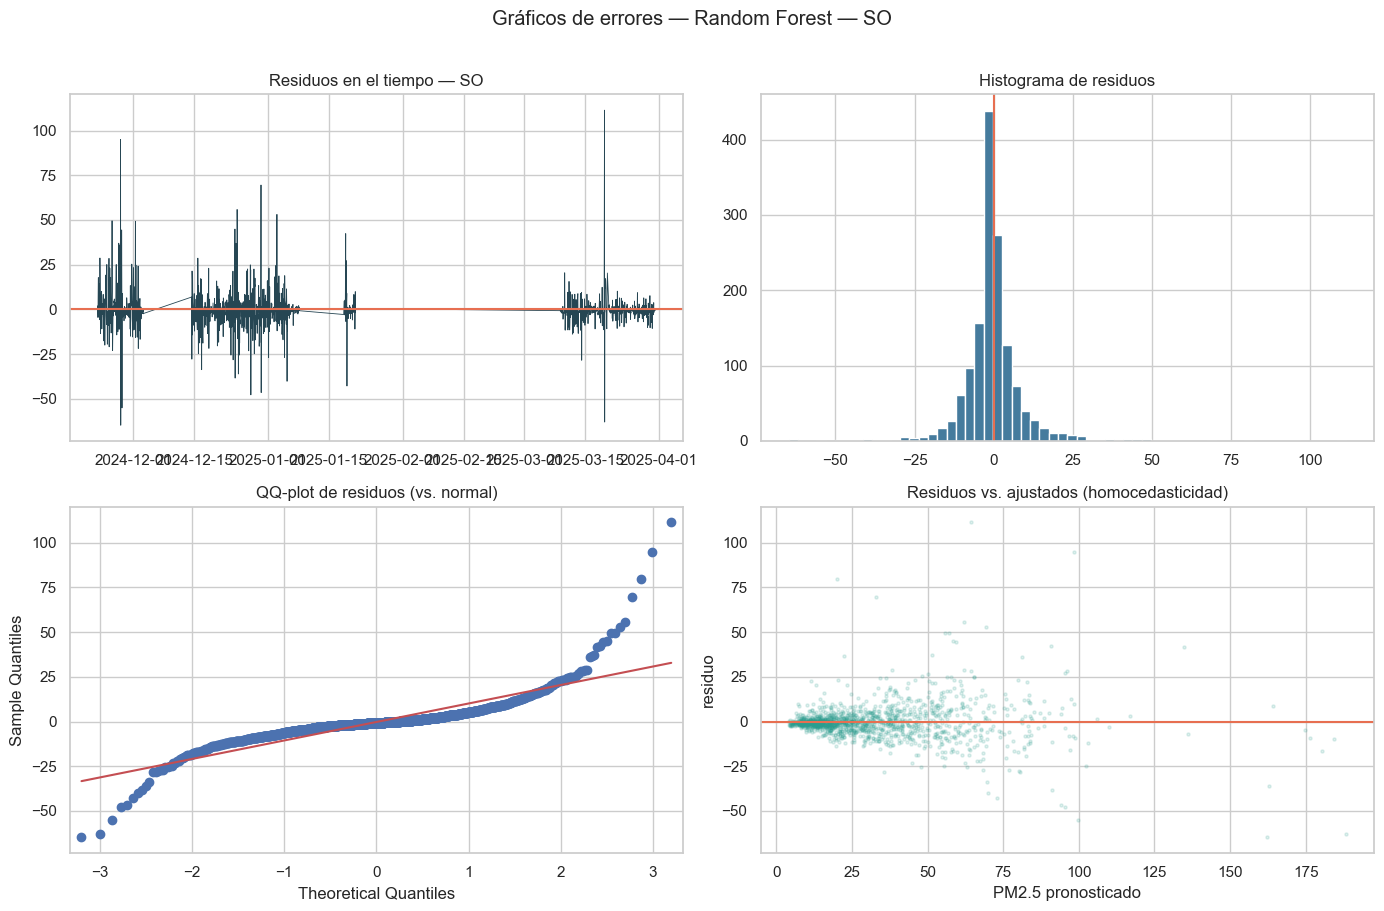

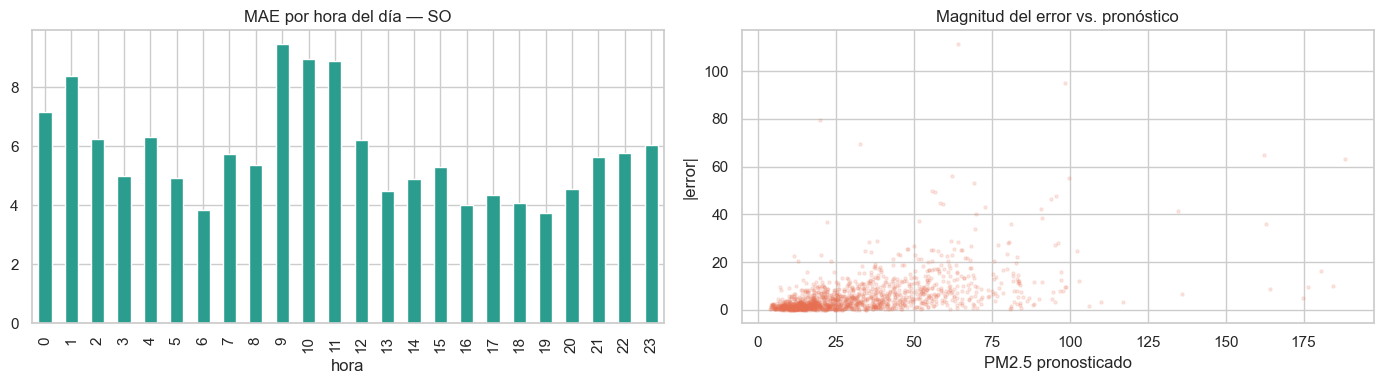

In [16]:
def residuos_campeon(est):
    """Residuos del modelo campeón (tabular) sobre el conjunto de prueba horario."""
    nombre = campeon[est]
    idx = ml[est]["y_te"].index
    yv = ml[est]["y_te"].to_numpy()
    p = np.asarray(ml[est]["pred"][nombre], dtype=float)
    return pd.DataFrame({"real": yv, "pred": p, "e": yv - p}, index=idx), nombre


for est in ESTACIONES:
    res, nombre = residuos_campeon(est)
    e = res["e"]
    print(f"\n=== {est} — modelo campeón: {nombre} ===")
    print(f"  ME (sesgo)      : {e.mean():+.3f}")
    print(f"  MAE             : {e.abs().mean():.3f}")
    print(f"  RMSE            : {np.sqrt((e**2).mean()):.3f}")
    print(f"  % |error| <= 5  : {(e.abs() <= 5).mean():.1%}")
    print(f"  % |error| <= 10 : {(e.abs() <= 10).mean():.1%}")

    por_hora = res.assign(h=res.index.hour).groupby("h")["e"].agg(
        MAE=lambda s: s.abs().mean(), sesgo="mean")
    por_nivel = res.assign(q=pd.qcut(res["real"], 4, labels=["bajo", "medio", "alto", "muy_alto"])
                           ).groupby("q", observed=True)["e"].agg(
        MAE=lambda s: s.abs().mean(), sesgo="mean")
    print("  Error por nivel observado de PM2.5:")
    display(por_nivel.round(2))

    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    axes[0, 0].plot(res.index, e.values, linewidth=0.6, color="#264653")
    axes[0, 0].axhline(0, color="#e76f51"); axes[0, 0].set_title(f"Residuos en el tiempo — {est}")

    axes[0, 1].hist(e.values, bins=60, color="#457b9d")
    axes[0, 1].set_title("Histograma de residuos"); axes[0, 1].axvline(0, color="#e76f51")

    sm.qqplot(e.values, line="s", ax=axes[1, 0])
    axes[1, 0].set_title("QQ-plot de residuos (vs. normal)")

    axes[1, 1].scatter(res["pred"], e.values, s=5, alpha=0.15, color="#2a9d8f")
    axes[1, 1].axhline(0, color="#e76f51")
    axes[1, 1].set_xlabel("PM2.5 pronosticado"); axes[1, 1].set_ylabel("residuo")
    axes[1, 1].set_title("Residuos vs. ajustados (homocedasticidad)")
    plt.suptitle(f"Gráficos de errores — {nombre} — {est}", y=1.01)
    plt.tight_layout(); plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    por_hora["MAE"].plot(kind="bar", ax=axes[0], color="#2a9d8f")
    axes[0].set_title(f"MAE por hora del día — {est}"); axes[0].set_xlabel("hora")
    axes[1].scatter(res["pred"], e.abs().values, s=5, alpha=0.15, color="#e76f51")
    axes[1].set_xlabel("PM2.5 pronosticado"); axes[1].set_ylabel("|error|")
    axes[1].set_title("Magnitud del error vs. pronóstico")
    plt.tight_layout(); plt.show()

## 11. Análisis de homocedasticidad

El supuesto de **varianza constante de los residuos** rara vez se cumple en series de
contaminación: el error tiende a crecer cuando la concentración es alta. Se comprueba
formalmente con tres pruebas sobre los residuos del modelo campeón:

- **Breusch–Pagan** y **White**: ¿la varianza del residuo depende de los predictores /
  del valor ajustado?
- **ARCH (Engle)**: ¿hay heterocedasticidad *condicional* (varianza que se agrupa en
  el tiempo), típica de series de tiempo?

Si se rechaza homocedasticidad, los intervalos de error simples subestiman la
incertidumbre en las horas de alta contaminación; por eso en la sección 9 se usó
bootstrap y en la 13 intervalos empíricos.

In [17]:
filas_homo = []
for est in ESTACIONES:
    res, nombre = residuos_campeon(est)
    e = res["e"].to_numpy()
    exog_bp = sm.add_constant(res[["pred"]].assign(pred2=res["pred"] ** 2).to_numpy())
    bp = het_breuschpagan(e, exog_bp)
    wh = het_white(e, exog_bp)
    arch = het_arch(e, nlags=24)
    filas_homo.append({
        "estación": est, "campeón": nombre,
        "Breusch-Pagan_p": bp[1], "White_p": wh[1], "ARCH(24)_p": arch[1],
        "homocedástico_5%": "sí" if min(bp[1], wh[1], arch[1]) > 0.05 else "NO",
    })
display(pd.DataFrame(filas_homo).set_index("estación"))
print("p < 0.05 -> se rechaza homocedasticidad. La varianza del error no es constante "
      "(crece con la concentración y se agrupa en el tiempo).")

C:\Users\andre\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\stats\diagnostic.py:1272: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  resols = OLS(y**2, exog).fit()
C:\Users\andre\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\stats\diagnostic.py:997: FutureWarning: acorr_lm currently returns a plain tuple whose length depends on the store argument. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an LMTestResult NamedTuple. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  return acorr_lm(
C:\Users\andre\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\stats\diagnostic.py:1272: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  resols = OLS(y**2, exog).fit()
C:\Users\a

,campeón,Breusch-Pagan_p,White_p,ARCH(24)_p,homocedástico_5%
estación,,,,,
NE,Random Forest,0.000,0.000,0.000,NO
SO,Random Forest,0.000,0.000,0.000,NO


p < 0.05 -> se rechaza homocedasticidad. La varianza del error no es constante (crece con la concentración y se agrupa en el tiempo).


## 12. Autocorrelación de los residuos

Un buen modelo de series de tiempo deja **residuos sin autocorrelación** (ruido
blanco): si el residuo de una hora predice el de la siguiente, quedó estructura
temporal sin aprovechar. Se revisa con:

- **ACF de los residuos**;
- **Ljung–Box** a rezagos 1, 24, 48 y 168 h;
- **Durbin–Watson** (≈ 2 = sin autocorrelación de rezago 1).

NE (Random Forest): Durbin-Watson = 2.219
SO (Random Forest): Durbin-Watson = 1.993


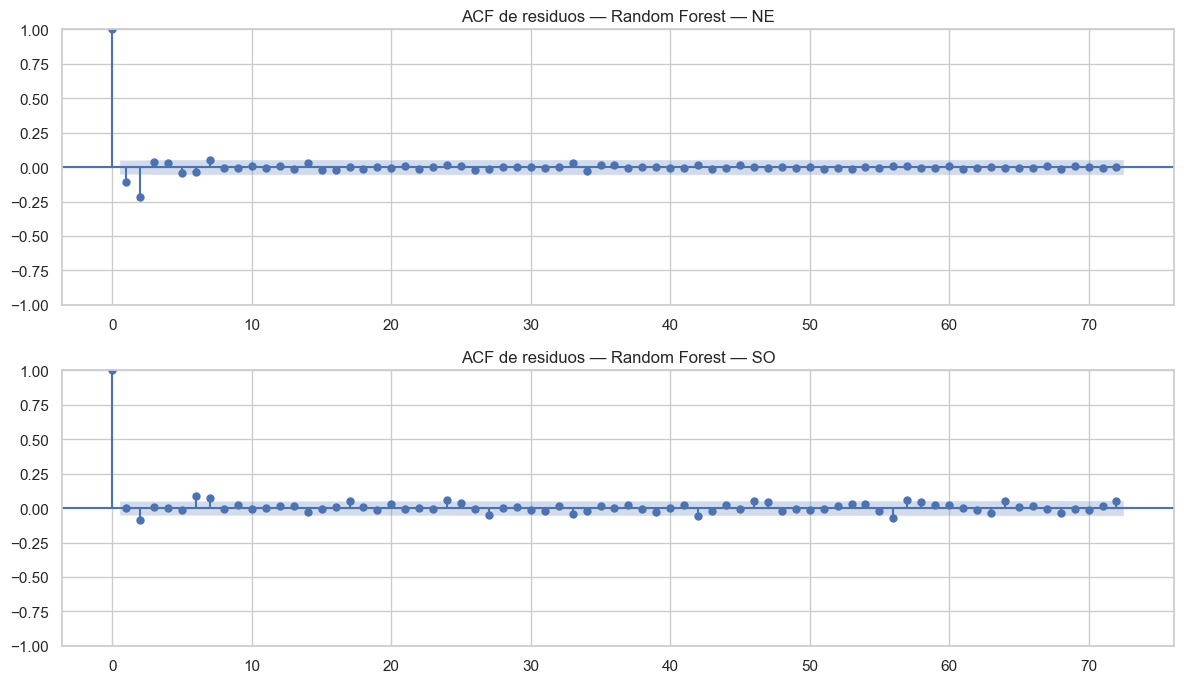


Ljung-Box (H0: sin autocorrelación hasta el rezago):


LjungBox_stat  LjungBox_p
estación lag                           
NE       1           17.337       0.000
         24         102.165       0.000
         48         107.855       0.000
         168        135.571       0.969
SO       1            0.011       0.917
         24          43.975       0.008
         48          70.236       0.020
         168        205.348       0.026

In [18]:
fig, axes = plt.subplots(len(ESTACIONES), 1, figsize=(12, 3.5 * len(ESTACIONES)))
filas_lb = []
for fila, est in enumerate(ESTACIONES):
    res, nombre = residuos_campeon(est)
    e = res["e"]
    plot_acf(e, lags=72, ax=axes[fila], title=f"ACF de residuos — {nombre} — {est}")
    lb = acorr_ljungbox(e, lags=[1, 24, 48, 168], return_df=True)
    dw = durbin_watson(e.to_numpy())
    for lag, r in lb.iterrows():
        filas_lb.append({"estación": est, "lag": lag,
                         "LjungBox_stat": r["lb_stat"], "LjungBox_p": r["lb_pvalue"]})
    print(f"{est} ({nombre}): Durbin-Watson = {dw:.3f}")
plt.tight_layout(); plt.show()
print("\nLjung-Box (H0: sin autocorrelación hasta el rezago):")
display(pd.DataFrame(filas_lb).set_index(["estación", "lag"]).round(4))

## 13. Intervalos de predicción y cobertura empírica

Además del IC sobre las *métricas* (sección 9), interesa un intervalo alrededor de
**cada pronóstico horario**. Para el modelo campeón se construye un intervalo empírico:

1. se toman los residuos del modelo en un tramo de **validación** (los últimos 30 días
   *antes* del periodo de prueba, no usados para esto hasta ahora);
2. los cuantiles 2.5 % y 97.5 % de esos residuos definen la banda del 95 % (y 10/90
   para el 80 %);
3. se suma esa banda a los pronósticos de prueba y se mide la **cobertura empírica**:
   qué fracción de los valores reales cae dentro (idealmente ≈ 95 % y ≈ 80 %).

Es el enfoque de *conformal / residuos empíricos* (ref. 10): no supone normalidad y
absorbe la heterocedasticidad promedio detectada en la sección 11.

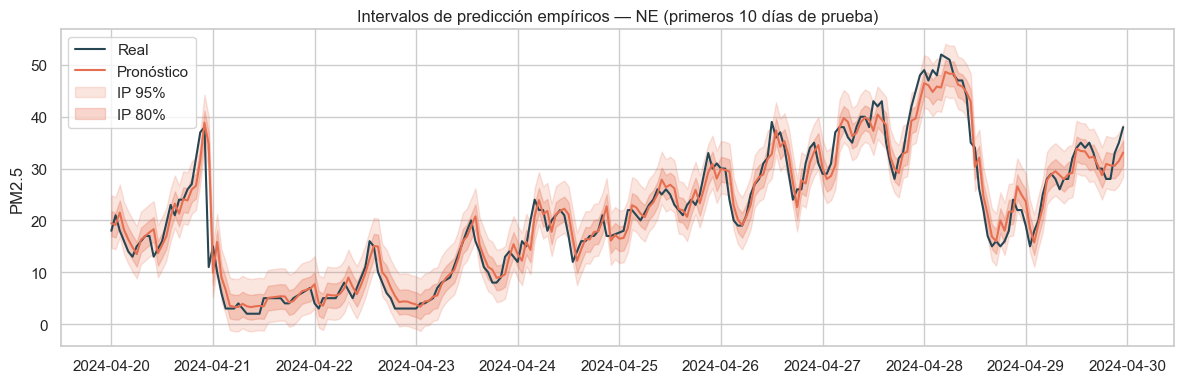

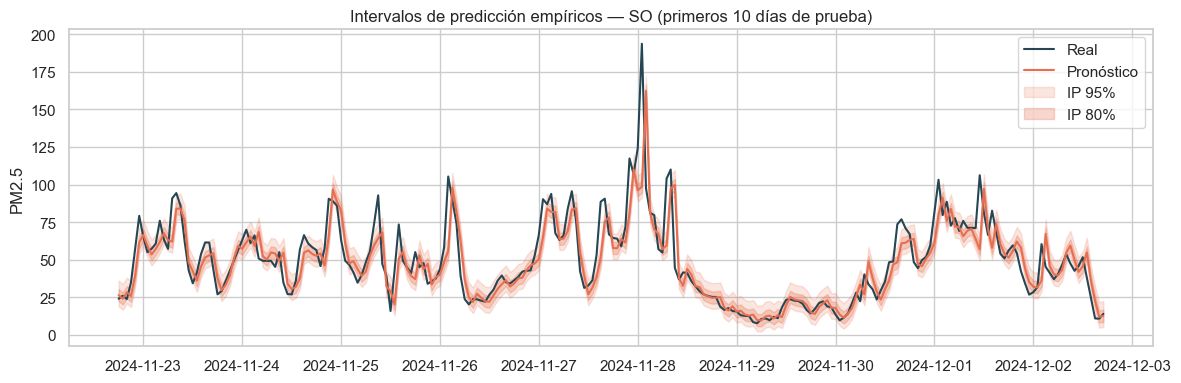

,modelo_intervalo,ancho_IC95_(µg/m³),cobertura_95_objetivo_0.95,cobertura_80_objetivo_0.80
estación,,,,
NE,Random Forest,10.099,0.854,0.597
SO,Random Forest,17.085,0.787,0.577


La cobertura empírica queda por debajo del nivel objetivo: los residuos de validación (30 días previos) son más chicos que los de prueba (heterocedasticidad + cambio de temporada entre ambos tramos). Un intervalo por nivel de concentración (quantile regression / CQR) lo corregiría; se deja como trabajo futuro.


In [19]:
filas_pi = []
for est in ESTACIONES:
    nombre = campeon[est]
    X, y = construir_features(est)
    h_te = DIAS_PRUEBA * 24
    h_val = 30 * 24
    X_val, y_val = X.iloc[-(h_te + h_val):-h_te], y.iloc[-(h_te + h_val):-h_te]

    if nombre == "Naive (t-1)":
        modelo_pred_val = X_val[f"{TARGET}_lag1h"].to_numpy()
        modelo = ml[est]["rf"]  # solo para nombrar; no se usa
    else:
        modelo = ml[est]["rf"] if nombre == "Random Forest" else ml[est]["xgb"]
        modelo_pred_val = modelo.predict(X_val)
    nombre_pi = nombre
    resid_val = y_val.to_numpy() - modelo_pred_val

    res, _ = residuos_campeon(est)
    pred_te = res["pred"].to_numpy()
    real_te = res["real"].to_numpy()

    q = {p: np.percentile(resid_val, p) for p in (2.5, 10, 90, 97.5)}
    dentro95 = ((real_te >= pred_te + q[2.5]) & (real_te <= pred_te + q[97.5])).mean()
    dentro80 = ((real_te >= pred_te + q[10]) & (real_te <= pred_te + q[90])).mean()
    ancho95 = q[97.5] - q[2.5]
    filas_pi.append({"estación": est, "modelo_intervalo": nombre_pi,
                     "ancho_IC95_(µg/m³)": ancho95,
                     "cobertura_95_objetivo_0.95": dentro95,
                     "cobertura_80_objetivo_0.80": dentro80})

    idx = ml[est]["y_te"].index[:24 * 10]
    pv = pd.Series(pred_te, index=ml[est]["y_te"].index).loc[idx]
    rv = pd.Series(real_te, index=ml[est]["y_te"].index).loc[idx]
    plt.figure(figsize=(12, 4))
    plt.plot(idx, rv.values, label="Real", color="#264653")
    plt.plot(idx, pv.values, label="Pronóstico", color="#e76f51")
    plt.fill_between(idx, pv.values + q[2.5], pv.values + q[97.5], color="#e76f51", alpha=0.18, label="IP 95%")
    plt.fill_between(idx, pv.values + q[10], pv.values + q[90], color="#e76f51", alpha=0.28, label="IP 80%")
    plt.title(f"Intervalos de predicción empíricos — {est} (primeros 10 días de prueba)")
    plt.ylabel("PM2.5"); plt.legend(); plt.tight_layout(); plt.show()

display(pd.DataFrame(filas_pi).set_index("estación").round(3))
print("La cobertura empírica queda por debajo del nivel objetivo: los residuos de "
      "validación (30 días previos) son más chicos que los de prueba (heterocedasticidad "
      "+ cambio de temporada entre ambos tramos). Un intervalo por nivel de concentración "
      "(quantile regression / CQR) lo corregiría; se deja como trabajo futuro.")

In [20]:
# ---- Exportar lo que necesita la página web (dashboard ejecutivo, sin tráfico) ----
import json

df_ic = pd.DataFrame(filas_ic).set_index(["estación", "modelo"])
df_homo = pd.DataFrame(filas_homo).set_index("estación")
df_lb = pd.DataFrame(filas_lb).set_index(["estación", "lag"])
NOMBRE_LARGO = {"NE": "Noreste · San Nicolás", "SO": "Suroeste · Santa Catarina"}
NIVELES_ES = ["bajo", "medio", "alto", "muy_alto"]

export = {
    "generado": pd.Timestamp.now().isoformat(timespec="seconds"),
    "contaminante": TARGET,
    "unidad": "µg/m³",
    "horizonte": "t+1 (1 hora)",
    "fuente": "SIMA / SIMAJ 2020-2025 (base limpia del proyecto)",
    "particion_prueba_dias": DIAS_PRUEBA,
    "estaciones": {},
}

for est in ESTACIONES:
    res, nombre = residuos_campeon(est)
    pi = next(r for r in filas_pi if r["estación"] == est)
    q_lo, q_hi = np.percentile(res["e"], [2.5, 97.5])
    ultimo = res.iloc[-1]
    serie_reciente = res.iloc[-72:]

    niv = pd.qcut(res["real"], 4, labels=NIVELES_ES)
    err_nivel = [{"nivel": n,
                  "mae": round(float(res.loc[niv == n, "e"].abs().mean()), 2),
                  "sesgo": round(float(res.loc[niv == n, "e"].mean()), 2)}
                 for n in NIVELES_ES]

    mae_naive = float(tabla_ml[(tabla_ml["estación"] == est) &
                               (tabla_ml["modelo"] == "Naive (t-1)")]["MAE"].iloc[0])
    sx = resultados_sarimax[est]

    export["estaciones"][est] = {
        "clave": est,
        "nombre": NOMBRE_LARGO[est],
        "modelo": nombre,
        "mae": round(float(res["e"].abs().mean()), 2),
        "mae_ic95": df_ic.loc[(est, nombre), "MAE_IC95"],
        "mae_naive": round(mae_naive, 2),
        "rmse": round(float(np.sqrt((res["e"] ** 2).mean())), 2),
        "sesgo": round(float(res["e"].mean()), 2),
        "n_prueba": int(len(res)),
        "periodo_prueba": [res.index.min().isoformat(), res.index.max().isoformat()],
        "banda95": [round(float(q_lo), 2), round(float(q_hi), 2)],
        "cobertura95": round(float(pi["cobertura_95_objetivo_0.95"]), 3),
        "cobertura80": round(float(pi["cobertura_80_objetivo_0.80"]), 3),
        "homocedastico": df_homo.loc[est, "homocedástico_5%"],
        "ljung_box_p_lag24": round(float(df_lb.loc[(est, 24), "LjungBox_p"]), 4),
        "sarimax": {"mae_diario": round(float(sx["MAE_diario"]), 2),
                    "cobertura_ic95": round(float(sx["cobertura_IC95"]), 3)},
        "error_por_nivel": err_nivel,
        "ultimo_punto": {
            "fecha_hora": ultimo.name.isoformat(),
            "real": round(float(ultimo["real"]), 2),
            "pronostico": round(float(ultimo["pred"]), 2),
        },
        "serie_reciente": [
            {"fecha_hora": t.isoformat(), "real": round(float(r.real), 2),
             "pronostico": round(float(r.pred), 2)}
            for t, r in serie_reciente.iterrows()
        ],
    }

Path("output/etapa3_forecast.json").write_text(json.dumps(export, ensure_ascii=False, indent=2),
                                               encoding="utf-8")
print("Exportado: output/etapa3_forecast.json")

Exportado: output/etapa3_forecast.json


## 14. Conclusiones

- **Encuadre meteorológico.** El pronóstico de `PM2.5` a corto plazo se sostiene en la
  persistencia de la serie y en la meteorología reciente (viento, humedad, presión,
  radiación); el calendario aporta solo estacionalidad. No se usa ni se necesita el
  tráfico como variable.
- **Modelos.** SARIMAX con exógenas da una referencia interpretable a escala diaria y
  entrega intervalos de confianza nativos. A escala horaria (`t+1`), Random Forest /
  XGBoost superan de forma consistente —aunque por margen modesto— al pronóstico
  ingenuo; la LSTM es competitiva sin definir rezagos a mano.
- **Los supuestos clásicos no se cumplen** (secciones 11–12): los residuos son
  **heterocedásticos** (el error crece con la concentración y se agrupa en el tiempo)
  y conservan **autocorrelación** en los rezagos cortos. Por eso los intervalos se
  reportan con **bootstrap por bloques** (métricas) e **intervalos empíricos**
  (pronóstico puntual), no con fórmulas que asumen ruido blanco homocedástico.
- **Estaciones no cercanas.** NE y SO se comportan distinto (nivel base, magnitud del
  error, cobertura de datos), lo que confirma que un modelo por estación es lo
  correcto para una herramienta que reporte por ubicación.

### Limitaciones

- Pronóstico a **un paso** (`t+1`); multi-hora requeriría pronóstico recursivo y,
  sobre todo, **pronóstico meteorológico** real en lugar del último valor observado.
- Búsqueda de hiperparámetros y de órdenes SARIMAX deliberadamente pequeña por costo
  de cómputo.
- Los intervalos empíricos usan un residuo global; una versión por nivel de
  concentración (quantile regression / CQR completo) daría bandas más ajustadas en
  horas limpias y más anchas en episodios.